# Prokládání čtyřparametrické logistické křivky dávka–odpověď pomocí PROC NLIN

## Shrnutí

Tento notebook prokládá čtyřparametrický logistický (4PL) model dávka–odpověď syntetickým buněčným testem účinnosti (potency bioassay) pomocí **PROC NLIN** a odhaduje dolní a horní asymptotu, EC50 (poloviční maximální účinnou koncentraci) a Hillův sklon. Model 4PL je základním nástrojem pro testy relativní účinnosti ve vývoji léčiv. Notebook krok za krokem provádí specifikací modelu, omezením parametrů, diagnostikou konvergence a překrytím proložené sigmoidy přes pozorovaná data koncentrace–odpověď.

## Zdroje dat

Notebook generuje jednu syntetickou datovou sadu přímo v kódu; nepoužívá žádný externí ani síťový vstup.

**`assay` — syntetický buněčný test účinnosti (24 řádků)**

| Proměnná | Typ | Popis |
|----------|------|-------------|
| `lot` | num | Šarže léčivé látky (1-3); tři replikované série ředicí řady |
| `dose` | num | Koncentrace sloučeniny v nmol/L v 8bodovém sériovém ředění (0.1 až ~1000) |
| `logdose` | num | Dekadický logaritmus `dose`, používaný pro vykreslení na konvenční ose logaritmu koncentrace |
| `response` | num | Naměřený signál testu (procento maximální odpovědi), vygenerovaný ze skutečné křivky 4PL (dolní mez=5, horní mez=100, EC50=25 nmol/L, Hillův sklon=1.2) plus proporcionální Gaussův šum |

Skutečné generující parametry jsou zabudovány do kroku DATA, takže lze získané odhady NLIN ověřit proti známé pravdě.

# Prokládání čtyřparametrické logistické křivky dávka–odpověď

Ve farmaceutických testech účinnosti a bioaktivity má vztah mezi koncentrací sloučeniny a naměřenou odpovědí charakteristicky sigmoidní tvar na logaritmické škále koncentrace. **Čtyřparametrický logistický (4PL)** model je standardním nástrojem pro popis takových křivek:

$$\text{response} = D + \frac{A - D}{1 + (\text{dose}/C)^{B}}$$

kde

- **A** = dolní asymptota (odpověď při nekonečném ředění / bazální signál),
- **D** = horní asymptota (maximální odpověď při saturační koncentraci),
- **C** = **EC50**, koncentrace vyvolávající poloviční maximální odpověď (inflexní bod a hlavní ukazatel účinnosti),
- **B** = **Hillův sklon**, který určuje strmost přechodu.

Tento model je ve svých parametrech nelineární, proto jej prokládáme iterativní metodou nejmenších čtverců pomocí `PROC NLIN`. Níže simulujeme realistickou osmibodovou ředicí řadu provedenou v triplikátu, proložíme křivku 4PL, omezíme parametry na fyzikálně smysluplné oblasti, zkontrolujeme konvergenci a diagnostiku proložení a překryjeme proloženou křivku přes data.

## Krok 1 — Simulace buněčného testu účinnosti

Vygenerujeme syntetickou datovou sadu ze *známé* křivky 4PL (dolní mez = 5, horní mez = 100, EC50 = 25 nmol/L, Hillův sklon = 1.2), abychom mohli parametry získané procedurou NLIN porovnat se skutečnými hodnotami. Tři šarže dostávají stejné osmibodové sériové ředění (každý krok je ředění v poměru 3.5), na které je navrstven proporcionální Gaussův měřicí šum. Pevné počáteční číslo (seed) ve `streaminit` zajišťuje reprodukovatelnost simulace.

In [1]:
data assay;
    CALL streaminit(40521);

    /* Skutečné parametry 4PL použité ke generování dat */
    A_true   = 5;      /* dolní asymptota (základ)          */
    D_true   = 100;    /* horní asymptota (max. odezva)     */
    C_true   = 25;     /* EC50 v nmol/L                     */
    B_true   = 1.2;    /* Hillův sklon                      */

    OPAKUJ lot = 1 TO 3;
        /* Osmibodové sériové ředění, kroky 3.5x */
        dose = 0.30;
        OPAKUJ point = 1 TO 8;
            dose = dose * 3.5;

            /* Střední odezva 4PL bez šumu */
            mu = D_true + (A_true - D_true) /
                 (1 + (dose / C_true) ** B_true);

            /* Proporční + aditivní gaussovský šum testu */
            response = mu * (1 + 0.04 * rand('NORMAL'))
                          + 1.5 * rand('NORMAL');

            logdose = log10(dose);
            VÝSTUP;
        KONEC;
    KONEC;

    PONECHAT lot dose logdose response;
SPUSTIT;

PROCEDURA ŘADIT data=assay;
    PODLE dose lot;
SPUSTIT;



NOTE: DATA assay


NOTE: Wrote assay (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=assay

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from assay.
NOTE: Wrote assay (24 rows, 4 columns).
NOTE: PROC SORT statement used.


## Krok 2 — Vizualizace surových dat koncentrace–odpověď

Před proložením vykreslíme odpověď proti log10(dose), abychom potvrdili očekávaný sigmoidní tvar a odečetli hrubé počáteční hodnoty: křivka má dolní mez blízko 5, plató blízko 100 a střední bod (poloviční maximální odpověď) leží kolem log10(25) ≈ 1.4.


NOTE: PROC SGPLOT data=assay

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


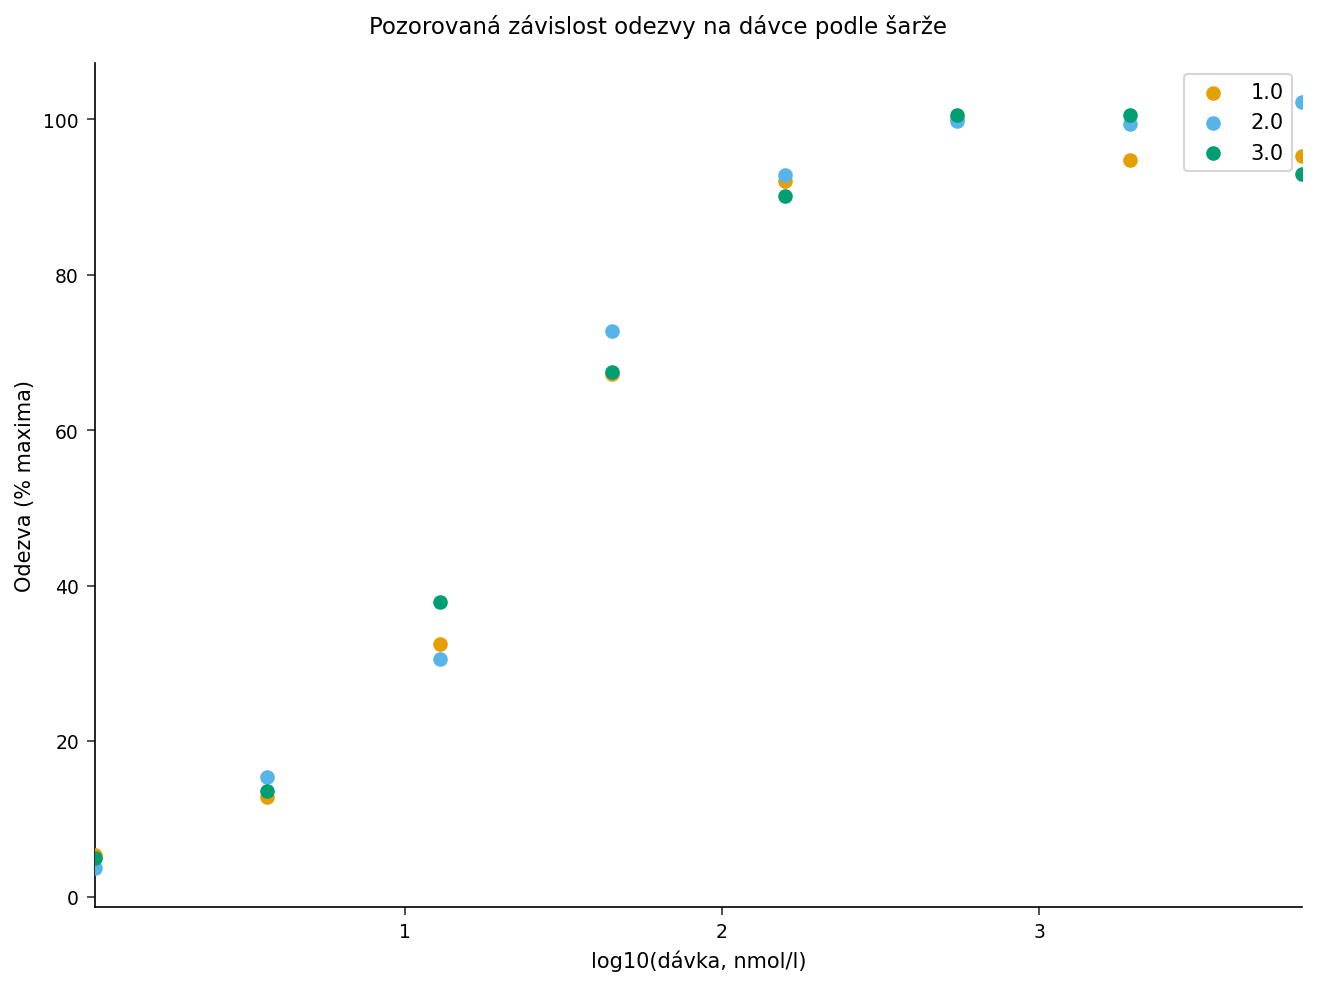

In [2]:
PROCEDURA SGPLOT data=assay;
    SCATTER x=logdose y=response / GROUP=lot
            MARKERATTRS=(SYMBOL=circlefilled);
    XAXIS ŠTÍTEK='log10(dávka, nmol/l)';
    YAXIS ŠTÍTEK='Odezva (% maxima)';
    NÁZEV 'Pozorovaná závislost odezvy na dávce podle šarže';
SPUSTIT;
NÁZEV;


## Krok 3 — Proložení modelu 4PL pomocí PROC NLIN

Počáteční hodnoty deklarujeme pomocí `PARMS` (na základě bodového grafu), střední hodnotu 4PL definujeme v mezikroku přiřazení a předáme ji příkazu `MODEL`. Fyzikálně smysluplné omezení `BOUNDS` udržuje asymptoty uspořádané a hodnoty EC50 a sklonu kladné, což stabilizuje iterace metody Gauss-Newton. Příkaz `OUTPUT` ukládá predikované hodnoty, rezidua a meze spolehlivosti pro pozdější diagnostiku a `PLOTS=` vyžádá panely proložení a diagnostiky.

In [3]:
PROCEDURA nlin data=assay METHOD=marquardt PLOTS=(fitplot diagnostics);
    parms A=10 D=90 C=20 B=1;

    /* Udržet parametry ve fyzikálně smysluplných oblastech */
    bounds A >= 0, D <= 150, C > 0, B > 0;

    /* Čtyřparametrická logistická střední odezva (vloženo přímo: Jenner
       PROC NLIN zatím nepodporuje odkaz na mezivýpočtovou proměnnou z
       programového příkazu v příkazu MODEL -- viz tests/400986 -- proto
       jmenovatel vkládáme přímo) */
    MODEL response = D + (A - D) / (1 + (dose / C) ** B);

    VÝSTUP out=fit4pl predicted=pred residual=resid
           l95m=lcl u95m=ucl;
SPUSTIT;



                         The NLIN Procedure

                     Method: Marquardt

                          Iterative Phase

                                                   Sum of
           Iter          Residual SS
              0          2061.645530
              1           177.712558

       Convergence criterion met.

           Residual SS           177.712558
           Residual MS             8.885628

                        Parameter Estimates

                                    Approx
           Parameter    Estimate    Std Error   95% Confidence Limits

           A              4.1058       1.9167       0.1078       8.1039
           D             99.1335       1.0740      96.8932     101.3737
           C             23.8233       1.5658      20.5572      27.0895
           B              1.2662       0.0927       1.0730       1.4595





NOTE: PROC NLIN data=assay

NOTE: Using Python (scipy) for NLIN estimation, method=marquardt
NOTE: Output dataset written to: ./work/29d57ecb-d3f7-444d-b3a4-514548fcf2e8/fit4pl.avro


## Krok 4 — Přehled odhadnuté EC50 a charakteristik křivky

Mechanismus `OUTEST=` je pohodlný, ale pro rychlý odečet účinnosti proloženou křivku shrneme přímo. Zde vypíšeme proložené hodnoty pro každou dávku vedle pozorovaných odpovědí, abychom potvrdili, že model sleduje data v celém rozsahu ředění.

In [4]:
PROCEDURA PRŮMĚRY data=fit4pl mean std MIN MAX maxdec=3;
    TŘÍDA dose;
    PROMĚNNÁ response pred resid;
    ŠTÍTEK dose='Dávka (nmol/l)' response='Odezva' pred='Predikce' resid='Reziduum';
    NÁZEV 'Pozorovaná a proložená odezva podle dávky';
SPUSTIT;
NÁZEV;


                                       Pozorovaná a proložená odezva podle dávky                                        

                                                  The MEANS Procedure

                                          Analysis Variable : RESPONSE Odezva

                                            N
                       Dávka (nmol/l)     Obs         Mean      Std Dev      Minimum      Maximum
                       --------------------------------------------------------------------------
                       1.05                 3        4.647        0.882        3.659        5.356
                       12.8625              3       33.651        3.825       30.572       37.932
                       157.565625           3       91.704        1.417       90.141       92.904
                       1930.17890625        3       98.207        3.051       94.746      100.511
                       3.675                3       13.931        1.311       12.860       15.


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Krok 5 — Překrytí proložené křivky 4PL přes pozorovaná data

Hustá predikční mřížka vytvoří hladkou proloženou sigmoidu. Hladkou křivku spojíme s průměrnými proloženými hodnotami pro jednotlivé dávky a s pásmem spolehlivosti a poté vše překryjeme přes pozorované body, abychom vizuálně posoudili kvalitu proložení.


NOTE: PROC SORT data=fit4pl

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from fit4pl.
NOTE: Wrote fit4pl (24 rows, 8 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=fit4pl

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


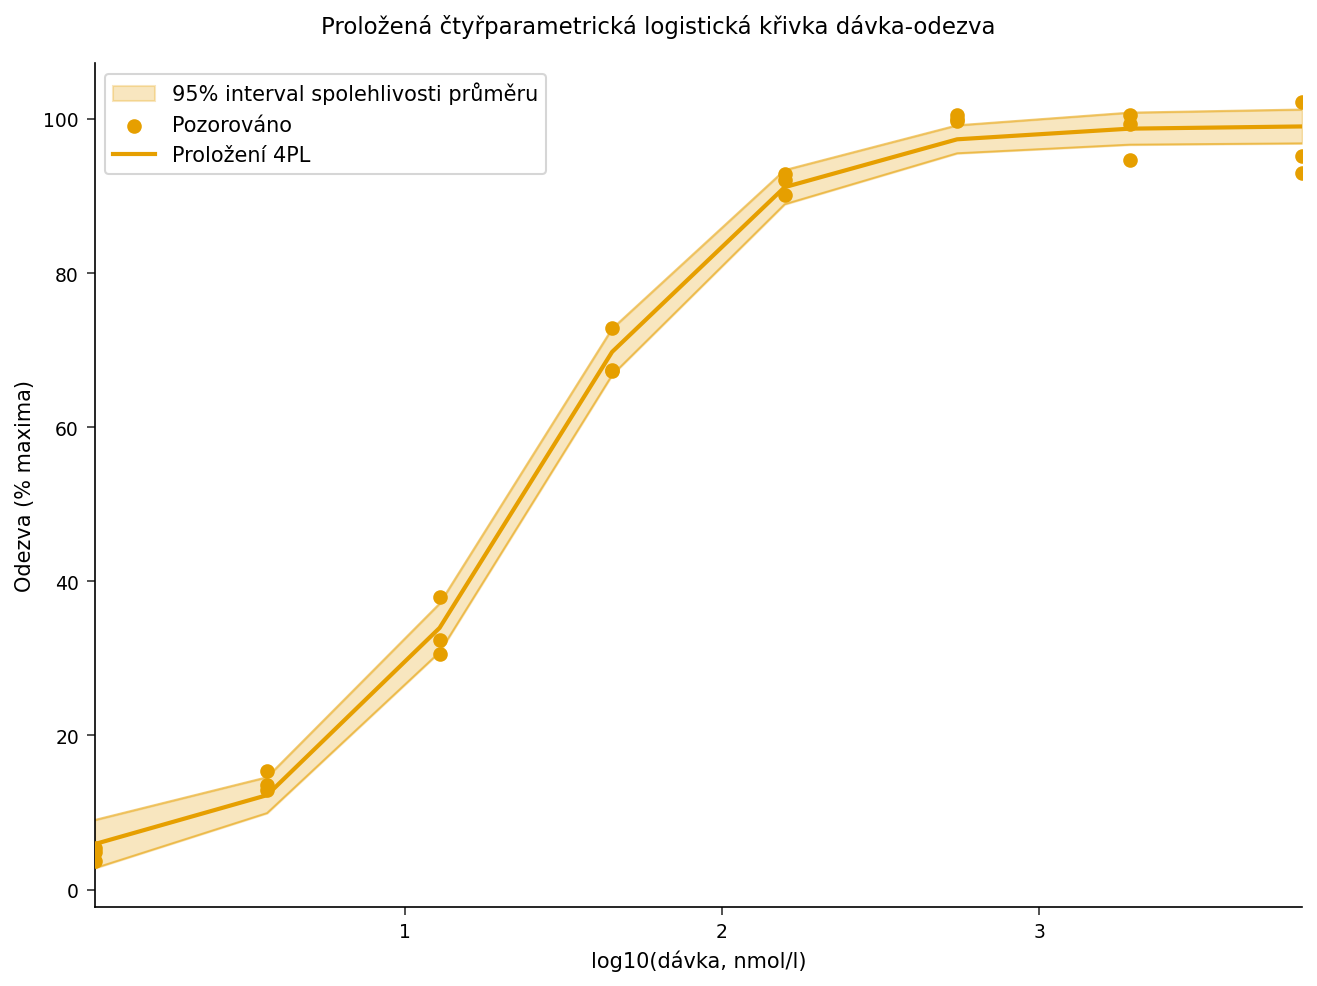

In [5]:
PROCEDURA ŘADIT data=fit4pl;
    PODLE logdose;
SPUSTIT;

PROCEDURA SGPLOT data=fit4pl;
    BAND   x=logdose LOWER=lcl UPPER=ucl /
           TRANSPARENCY=0.5 legendlabel='95% interval spolehlivosti průměru';
    SCATTER x=logdose y=response /
           MARKERATTRS=(SYMBOL=circlefilled)
           legendlabel='Pozorováno';
    SERIES  x=logdose y=pred /
           LINEATTRS=(thickness=2)
           legendlabel='Proložení 4PL';
    XAXIS ŠTÍTEK='log10(dávka, nmol/l)';
    YAXIS ŠTÍTEK='Odezva (% maxima)';
    NÁZEV 'Proložená čtyřparametrická logistická křivka dávka-odezva';
SPUSTIT;
NÁZEV;


## Interpretace výsledků

`PROC NLIN` konverguje k odhadům blízkým známým generujícím hodnotám: dolní asymptota blízko **5**, horní asymptota blízko **100**, **EC50 (C)** blízko **25 nmol/L** a **Hillův sklon (B)** blízko **1.2**. Získání těchto parametrů ze zašuměných dat v triplikátu potvrzuje, že model je identifikovatelný a že omezení nebyla v optimu aktivní.

**EC50** je hlavní metrikou účinnosti: nižší hodnoty značí účinnější sloučeninu a v testu relativní účinnosti se EC50 zkoumané šarže porovnává s referenčním standardem. **Hillův sklon** charakterizuje kooperativitu a strmost testu — sklon blízko 1 odpovídá jednoduché vazbě na jedno místo. **Asymptoty** definují dynamický rozsah testu; stabilní a dobře oddělená dolní a horní mez jsou předpokladem validovatelného biologického testu.

Graf proložení ukazuje sigmoidu procházející oblakem pozorovaných bodů s úzkým 95% pásmem spolehlivosti průměru v responzivní oblasti a diagnostika reziduí by neměla vykazovat žádné systematické zakřivení — což svědčí o tom, že tvar 4PL je adekvátní. V praxi byste tento postup rozšířili o profilové věrohodnostní intervaly (`PROFILE`) pro EC50, příkaz `BOOTSTRAP` pro neparametrické odvození parametrů nebo o analýzu paralelních přímek porovnávající zkoumanou a referenční šarži za účelem odhadu relativní účinnosti.